In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor 

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error

### Just change this if ever use this in future

In [2]:
# Setting Up A Default Path & Target
CSV_PATH = ("./Housing.csv")
TARGET_COL = "price"

In [3]:
df= pd.read_csv(CSV_PATH)

In [4]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


### Fix if needed

In [5]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Checking for encoded missing values

In [6]:
for col in df.columns:
    print(df[col].value_counts().head(20), "\n")

price
4200000    17
3500000    17
4900000    12
5250000     9
5600000     9
3150000     9
3640000     9
3290000     8
3360000     8
5950000     8
2940000     8
4550000     7
3010000     7
3920000     7
3850000     7
2660000     7
4270000     6
4690000     6
6650000     6
3430000     6
Name: count, dtype: int64 

area
6000    24
3000    14
4500    13
4000    11
6600     9
5500     9
3600     8
3180     7
4040     7
3640     7
3630     7
6360     7
5400     6
2145     6
3500     6
7000     5
3850     5
3450     5
4600     5
3480     5
Name: count, dtype: int64 

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64 

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64 

stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64 

mainroad
yes    468
no      77
Name: count, dtype: int64 

guestroom
no     448
yes     97
Name: count, dtype: int64 

basement
no     354
yes    191
Name: count, dtype: int64 

hotwaterheating
no

### Classifying the columns 
#### Numerical / Categorical

In [7]:
# Get numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Get categorical columns (Objects and Categories)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


### Data Visualization (Count Plot)

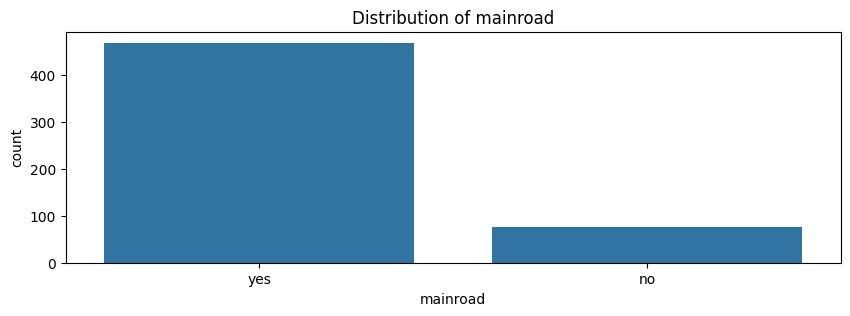

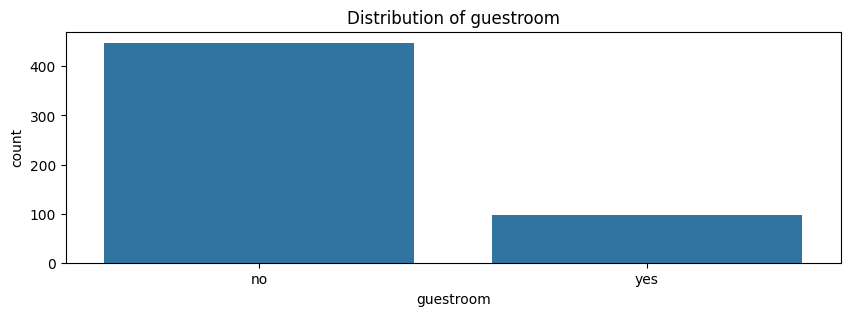

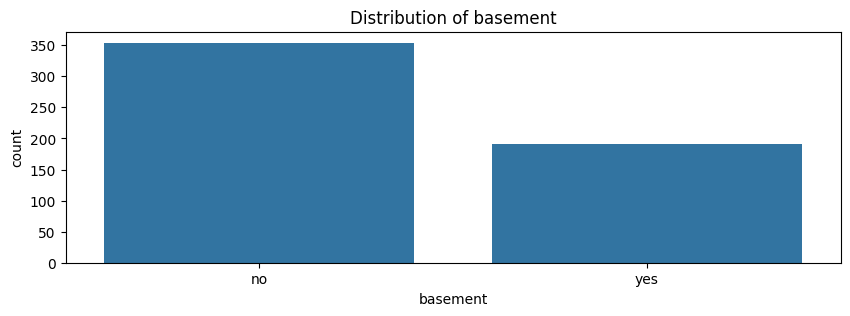

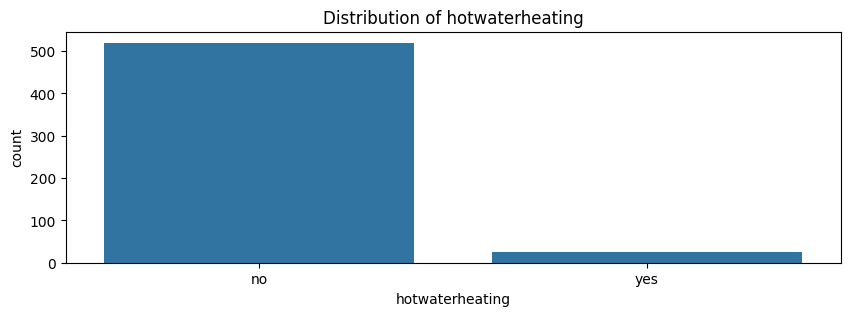

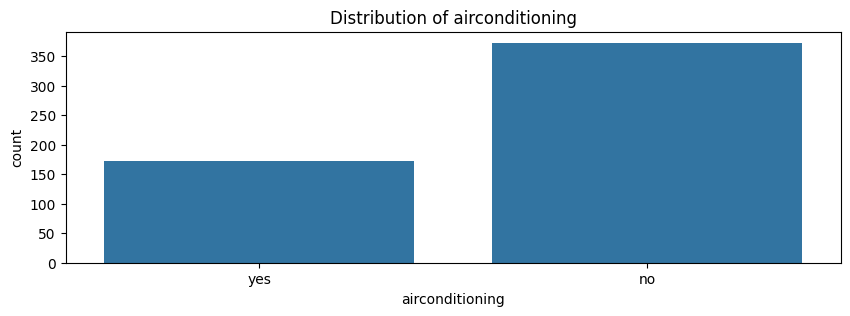

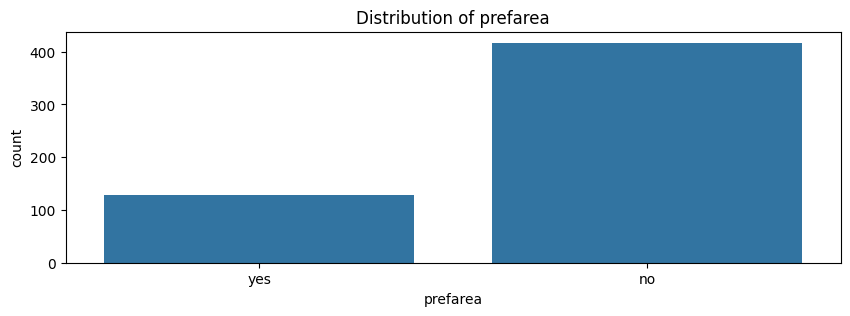

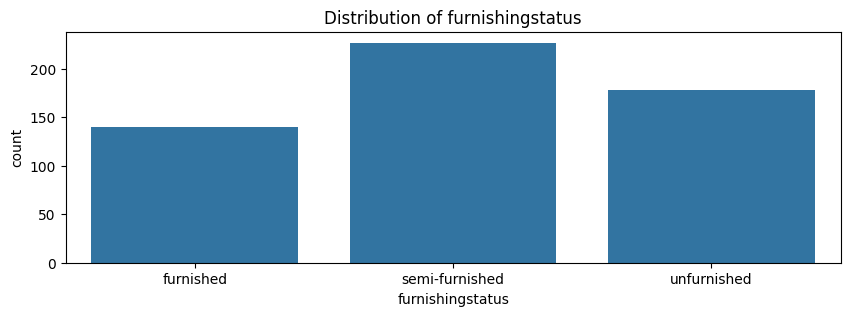

In [8]:
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

### Analyzing the target Column

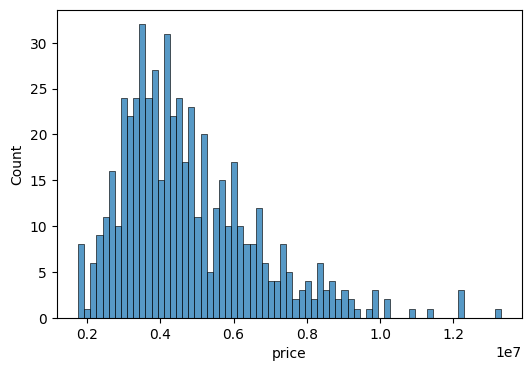

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=69)
plt.show()

### So this is Right Skewed will fix later

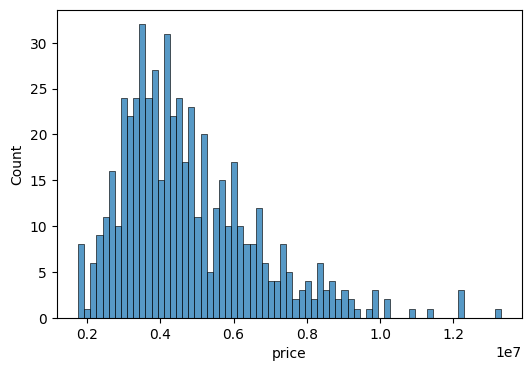

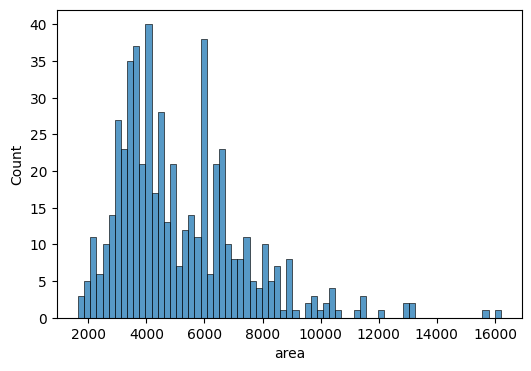

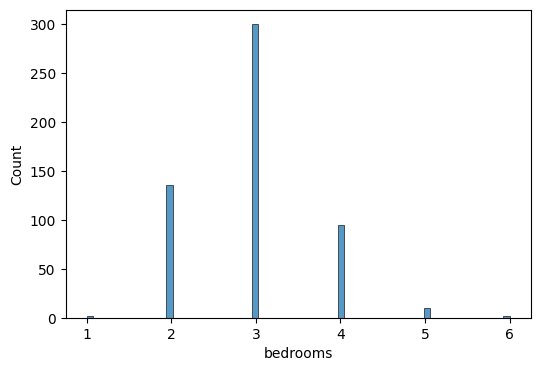

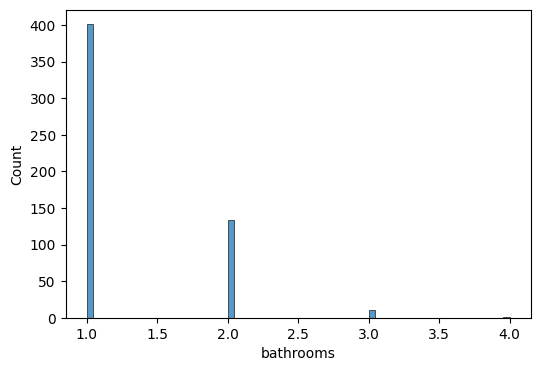

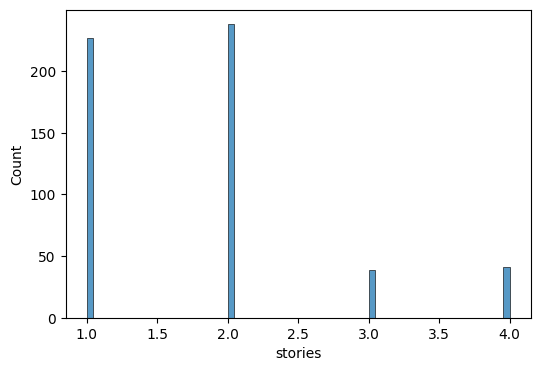

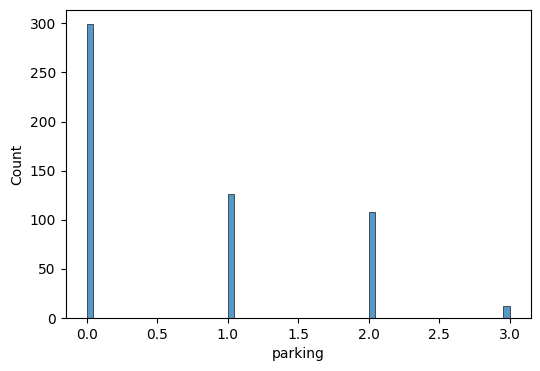

In [10]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=69)
    plt.show()

### Price, Area are Right Skewed

### Insights From The EDA

mainroad	Binary (0/1)
guestroom	Binary (0/1)
basement	Binary (0/1)
hotwaterheating	Binary (0/1)
airconditioning	Binary (0/1)
prefarea	Binary (0/1)
furnishingstatus	Ordinal	Clear hierarchy (None < Some < Full)

TargetColumn PRICE Right Skewed
AREA Right Skewed

# PREPROCESSING START

In [11]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [12]:
X.head(5)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [13]:
y.head(5)

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

### Creating TTS

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

### Creating ML Pipeline

In [15]:
num_cols

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

In [16]:
cat_cols

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [17]:
num_transformer = Pipeline(
    steps=[
        ("Imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

cat_transformer = Pipeline(
    steps=[
        ("Imputer", SimpleImputer(strategy="most_frequent")),
        ("OHE", OneHotEncoder(handle_unknown="ignore"))
        ])

In [18]:
preprocess = ColumnTransformer(
    transformers=[
        ("num",num_transformer,num_cols),
        ("cat",cat_transformer,cat_cols)
    ])

In [27]:
y = np.log1p(df["price"])

In [31]:
status_map = {
    "unfurnished": 0,
    "semi-furnished": 1,
    "furnished": 2
}
df["furnishingstatus"] = df["furnishingstatus"].map(status_map)

In [33]:
df.replace({"yes": 1, "no": 0}, inplace=True)

C:\Users\anuve\AppData\Local\Temp\ipykernel_19088\3136251882.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"yes": 1, "no": 0}, inplace=True)


In [35]:
df["area_log"] = np.log1p(df["area"])

In [36]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_log
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,8.912069
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,9.100637
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,9.206433
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,8.922792
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,8.912069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,8.006701
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,7.783641
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,8.194506
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2,7.976252


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

## Training Random Forest Regressor

In [48]:
model = RandomForestRegressor(random_state=42)

In [51]:
pipe = Pipeline([("preprocess",preprocess),
                 ("model",model)
                ])

In [60]:
pipe.fit(X_train,y_train)

ValueError: A given column is not a column of the dataframe

In [53]:
df["price_log"] = np.log1p(df["price"])

X = df.drop(columns=["price", "price_log"])
y = df["price_log"]

In [55]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_log,price_log
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,8.912069,16.403275
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,9.100637,16.321037
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,9.206433,16.321037
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,8.922792,16.318175
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,8.912069,16.250001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,8.006701,14.414348
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,7.783641,14.384879
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,8.194506,14.375127
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2,7.976252,14.375127


In [56]:
y

0      16.403275
1      16.321037
2      16.321037
3      16.318175
4      16.250001
         ...    
540    14.414348
541    14.384879
542    14.375127
543    14.375127
544    14.375127
Name: price_log, Length: 545, dtype: float64

In [57]:
print("Columns in df:", df.columns.tolist())
print("num_cols:", num_cols)
print("cat_cols:", cat_cols)

Columns in df: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'area_log', 'price_log']
num_cols: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
cat_cols: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [58]:
# ===== FIX KeyError: 'price' =====

# Create features & target FIRST
X = df.drop(columns=["price"])
y = df["price"]

# IMPORTANT: recompute column lists FROM X (not df)
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# Rebuild preprocessor with updated columns
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

In [61]:
# ===== HARD RESET FIX FOR KeyError: 'price' =====

# 1️⃣ Recreate X and y
X = df.drop(columns=["price"])
y = df["price"]

# 2️⃣ Recompute column lists (VERY IMPORTANT)
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

# 3️⃣ RECREATE preprocess completely (overwrite old one)
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# 4️⃣ RECREATE pipeline (old pipe still remembers 'price')
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

In [62]:
pipe.fit(X_train, y_train)

ValueError: A given column is not a column of the dataframe

In [63]:
print(X.columns)
print(num_cols)


Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus', 'area_log', 'price_log'],
      dtype='object')
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'area_log', 'price_log']


In [64]:
X = df.drop(columns=["price_log"])
y = df["price_log"]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)

ValueError: A given column is not a column of the dataframe